In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("dataset.csv")
df.head()

,text,clean_text,style,tone
0,"With a gentle, knowing smile, the old man hand...","with a gentle , know smile , the old man hand ...",literary,friendly
1,The meeting is scheduled to take place on Mond...,the meeting be schedule to take place on monda...,formal,neutral
2,We enthusiastically support interdisciplinary ...,we enthusiastically support interdisciplinary ...,academic,friendly
3,The authors have successfully proven what the ...,the author have successfully prove what the re...,academic,sarcastic
4,"Oh, what a grand and magnificent feast it was,...","oh , what a grand and magnificent feast it be ...",literary,sarcastic


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        250 non-null    str  
 1   clean_text  250 non-null    str  
 2   style       250 non-null    str  
 3   tone        250 non-null    str  
dtypes: str(4)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()

text          0
clean_text    0
style         0
tone          0
dtype: int64

style
literary    50
formal      50
academic    50
business    50
informal    50
Name: count, dtype: int64


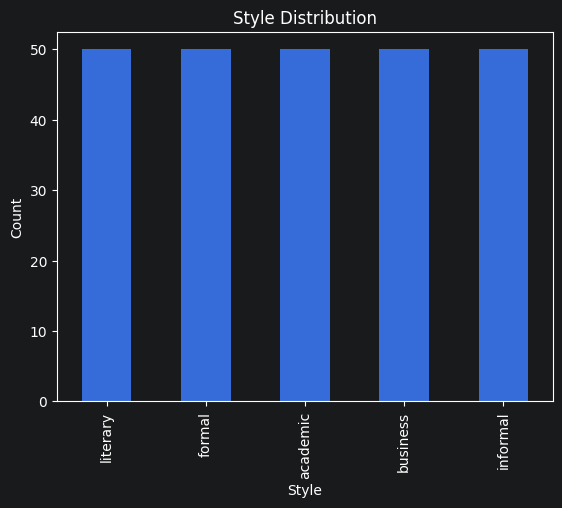

In [6]:
style_counts = df["style"].value_counts()

print(style_counts)

style_counts.plot(kind="bar")

plt.title("Style Distribution")
plt.xlabel("Style")
plt.ylabel("Count")

plt.show()

tone
friendly      52
sarcastic     50
aggressive    50
urgent        50
neutral       48
Name: count, dtype: int64


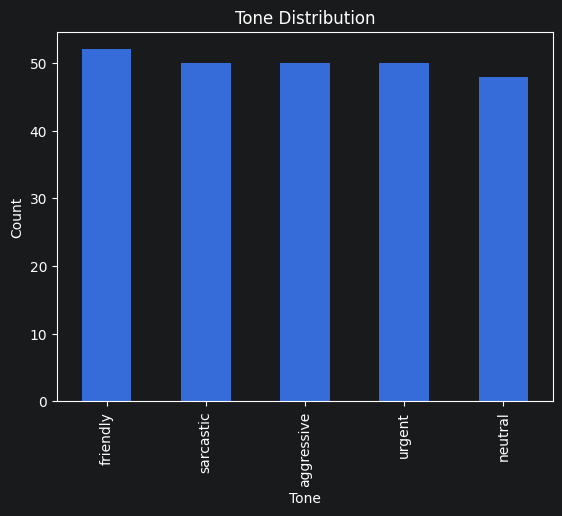

In [7]:
tone_counts = df["tone"].value_counts()

print(tone_counts)

tone_counts.plot(kind="bar")

plt.title("Tone Distribution")
plt.xlabel("Tone")
plt.ylabel("Count")

plt.show()

tone      aggressive  friendly  neutral  sarcastic  urgent
style                                                     
academic          10        10       10         10      10
business          10        10       10         10      10
formal            10        10       10         10      10
informal          10        12        8         10      10
literary          10        10       10         10      10


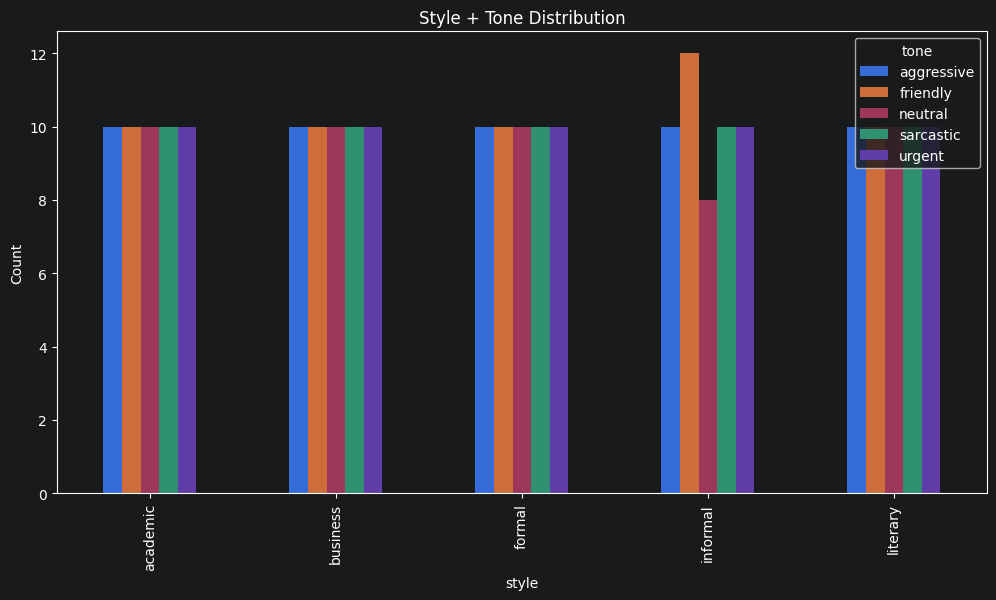

In [8]:
combo_counts = (
    df.groupby(["style", "tone"])
      .size()
      .unstack(fill_value=0)
)

print(combo_counts)

combo_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Style + Tone Distribution")
plt.ylabel("Count")

plt.show()

In [9]:
df["clean_text"] = df["text"].astype(str)
df["text_length"] = df["clean_text"].apply(len)

df["text_length"].describe()

count     250.000000
mean      127.500000
std       175.435482
min         9.000000
25%        83.250000
50%        93.000000
75%       101.000000
max      1194.000000
Name: text_length, dtype: float64

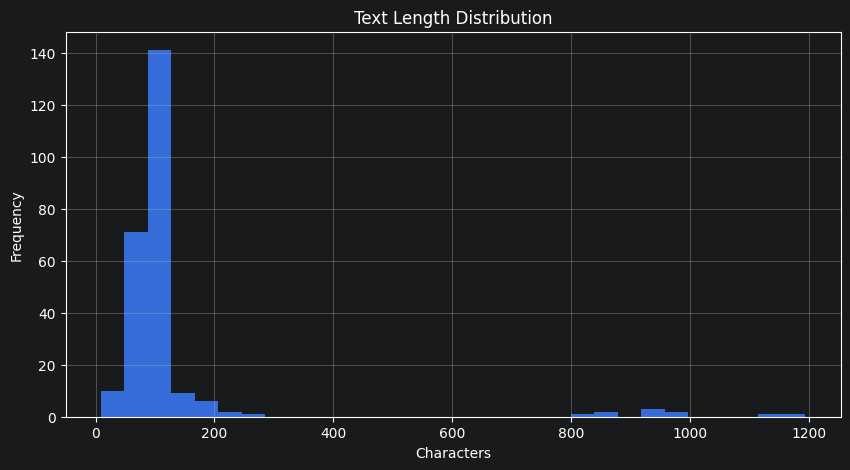

In [10]:
df["text_length"].hist(
    bins=30,
    figsize=(10, 5)
)

plt.title("Text Length Distribution")

plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()